In [1]:
import os
import torch
import torchvision
import mlflow
import random
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from PIL import Image
from datetime import datetime
from torchvision.utils import save_image

# Special imports of above dependencies:
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


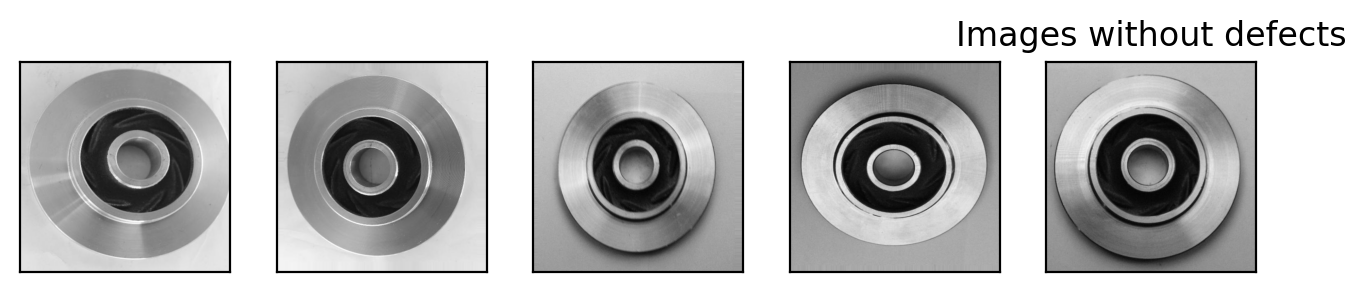

In [2]:
# Showing some samples of the dataset:

dataset_path_norm = "../data/raw/casting/casting_512x512/ok_front/" # Path to GOOD images dataset
dataset_path_def  = "../data/raw/casting/casting_512x512/def_front/" # Path to DEFECT images dataset
dataset_path_root = "../data/raw/casting/casting_512x512"


imgs_norm = os.listdir(os.path.join(dataset_path_norm)) # GOOD images
imgs_def  = os.listdir(os.path.join(dataset_path_def))  # DEFECT images

random.seed(42)

# Randomly sample 5 images per category:
samples_norm = random.sample(imgs_norm, 5)
samples_def  = random.sample(imgs_def, 5)

fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range(len(samples_norm)):
    ax = plt.subplot(2, 5, i + 1)
    imgNormPlot = Image.open(os.path.join(dataset_path_norm, samples_norm[i]))
    plt.imshow(imgNormPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.title("Images without defects", loc='center')
plt.show()

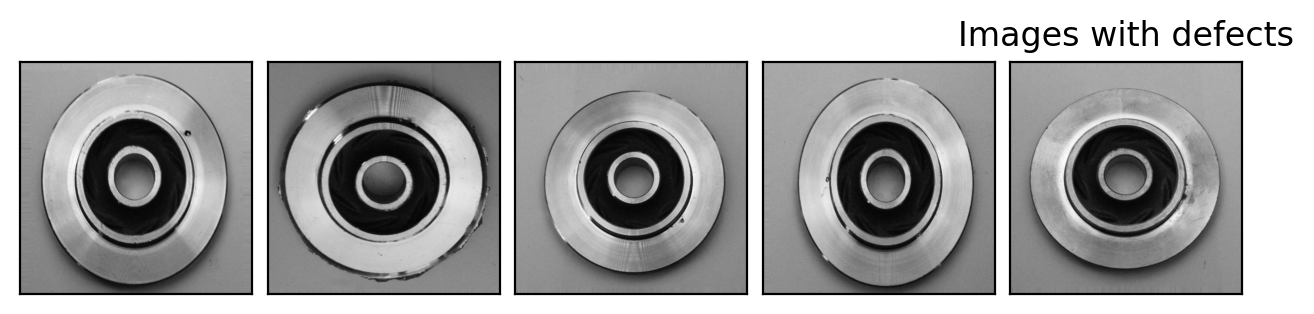

In [3]:
fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range (len(samples_def)):
    ax = plt.subplot(2, 5, i + 6)
    imgDefPlot = Image.open(os.path.join(dataset_path_def, samples_def[i]))
    plt.imshow(imgDefPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=-0.01, hspace=-0.01)

plt.title('Images with defects')
plt.show()

In [4]:
# Detecting if a GPU is available:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {torch.cuda.get_device_name(0)}") if device == "cuda" else print("No GPU available: Using CPU")

Device used: NVIDIA GeForce RTX 5080


In [5]:
class ResidualBlock(nn.Module):
    """
    Bloque Residual que mantiene la resolución y los canales intactos.
    Su única función es procesar y refinar texturas de alta frecuencia.
    """
    def __init__(self, channels):
        super().__init__()
        # Primera convolución (mantiene el tamaño gracias al padding=1)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        
        # Segunda convolución
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x # Guardamos la imagen original en la "Vía Rápida"
        
        # Pasamos por el camino largo
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # ¡LA MAGIA DE RESNET!: Sumamos la Vía Rápida antes de la activación final
        out += residual 
        return F.relu(out)

In [6]:
# ################################################################################################################################
# ####################################### Architecture of the Encoder (GoogleNet Encoder): #######################################
# ################################################################################################################################

class Encoder(nn.Module):
    def __init__(self, latent_dims, num_classes=2):
        super().__init__()
        
        # 1. Cargamos GoogLeNet base (sin clasificadores auxiliares)
        googlenet = models.googlenet(pretrained=False, aux_logits=False)
        
        # 2. Extraemos todas las capas EXCEPTO la última capa FC (fully connected)
        # Esto nos dejará con un vector de características de 1024 dimensiones
        self.feature_extractor = nn.Sequential(*list(googlenet.children())[:-1])
        
        # 3. La Fusión: 1024 características de la imagen + las clases condicionales
        self.fc_fusion = nn.Linear(1024 + num_classes, 512)
        
        # 4. Mapeo final al espacio latente z
        self.fc_mu = nn.Linear(512, latent_dims)
        self.fc_log_var = nn.Linear(512, latent_dims)

    def forward(self, x, label):
        # La imagen pasa sola por GoogLeNet
        features = self.feature_extractor(x)    # Salida: [batch, 1024, 1, 1]
        features = torch.flatten(features, 1)   # Salida: [batch, 1024]
        
        # Fusión Asimétrica en la capa FC (como dicta el paper)
        fused = torch.cat((features, label), dim=1) 
        fused = F.relu(self.fc_fusion(fused))
        
        mu = self.fc_mu(fused)
        log_var = self.fc_log_var(fused)
        
        return mu, log_var

In [7]:
# ##################################################################################################################################
# ####################################### Architecture of the Decoder (GoogleNet Generator): #######################################
# ##################################################################################################################################

class Decoder(nn.Module):
    def __init__(self, latent_dims, num_classes=2):
        super().__init__()
        
        # --- 2 Capas Totalmente Conectadas (FC) ---
        self.fc1 = nn.Linear(latent_dims + num_classes, 1024)
        # Asumimos que la entrada antes de las deconvoluciones es de 512 canales y 4x4
        self.fc2 = nn.Linear(1024, 512 * 4 * 4) 
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(512, 4, 4))
        
        # --- 6 Capas de Deconvolución (Upsampling 2-by-2) ---
        
        # Capa 1: Filtro 3x3 | Canales: 512 -> 256
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.res1 = ResidualBlock(256)
        
        # Capa 2: Filtro 3x3 | Canales: 256 -> 256
        self.deconv2 = nn.ConvTranspose2d(256, 256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        self.res2 = ResidualBlock(256)
        
        # Capa 3: Filtro 5x5 | Canales: 256 -> 128
        self.deconv3 = nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.res3 = ResidualBlock(128)
        
        # Capa 4: Filtro 5x5 | Canales: 128 -> 92
        self.deconv4 = nn.ConvTranspose2d(128, 92, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn4 = nn.BatchNorm2d(92)
        self.res4 = ResidualBlock(92)
        
        # Capa 5: Filtro 5x5 | Canales: 92 -> 64
        self.deconv5 = nn.ConvTranspose2d(92, 64, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        self.res5 = ResidualBlock(64)
        
        # Capa 6: Filtro 5x5 | Canales: 64 -> 3 (Imagen Final)
        self.deconv6 = nn.ConvTranspose2d(64, 3, kernel_size=5, stride=2, padding=2, output_padding=1)

    def forward(self, z, label):
        x = torch.cat((z, label), dim=1)
        
        # Pasamos por las FC
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.unflatten(x) # Se convierte en un mapa espacial de 4x4
        
        # Pasamos por las Deconvoluciones con Batch Normalization (como dicta el paper)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = self.res1(x)

        x = F.relu(self.bn2(self.deconv2(x)))
        x = self.res2(x)

        x = F.relu(self.bn3(self.deconv3(x)))
        x = self.res3(x)

        x = F.relu(self.bn4(self.deconv4(x)))
        x = self.res4(x)

        x = F.relu(self.bn5(self.deconv5(x)))
        x = self.res5(x)
        
        # La última capa siempre lleva Tanh para imágenes [-1, 1], sin BatchNorm
        x = torch.tanh(self.deconv6(x)) 
        
        return x

In [8]:
class CVAE(nn.Module):
    def __init__(self, latent_dims=100, num_classes=2):
        super().__init__()
        self.encoder = Encoder(latent_dims, num_classes)
        self.decoder = Decoder(latent_dims, num_classes)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)  # Compute standard deviation from log variance
        eps = torch.randn_like(std)     # Sample form standard normal distribution

        return mu + eps * std
    
    def forward(self, x, label):
        mu, log_var = self.encoder(x, label)
        z = self.reparametrize(mu, log_var)

        return self.decoder(z, label), mu, log_var

In [9]:
# ##################################################################################################################
# ####################################### Architecture of the Discriminator: #######################################
# ##################################################################################################################

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, num_classes=2):
        super(Discriminator, self).__init__()

        self.num_classes = num_classes

        self.feature_extractor = nn.Sequential(
            # Layer 1 --- Input: 3x256x256 -> Output: 64x128x128 ---
            nn.Conv2d(nc + num_classes, ndf, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2 --- Input: 64x128x128 -> Output: 128x64x64 ---
            nn.Conv2d(ndf, ndf * 2, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3 --- Input: 128x64x64 -> Output: 256x32x32 ---
            nn.Conv2d(ndf * 2, ndf * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4 --- Input: 256x32x32 -> Output: 512x16x16 ---
            nn.Conv2d(ndf * 4, ndf * 8, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 5 --- Input: 512x16x16 -> Output: 1024x8x8 ---
            nn.Conv2d(ndf * 8, ndf * 16, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            # Layer 6 --- Input 1024x8x8 -> Output 1x4x4 ---
            nn.Conv2d(ndf * 16, 1, 4, stride=2, padding=1, bias=False),
            #nn.Sigmoid() # Comment when using MSELoss
        )

    def forward(self, x, label):
        label_channel = label.unsqueeze(2).unsqueeze(3) # Expand dimensions: label_channel =  [1, 2, 1, 1] while x = [1, 3, 256, 256]
        label_channel = label_channel.expand(x.size(0), self.num_classes, x.size(2), x.size(3)) # label_channel = [1, 2, 256, 256]

        x = torch.cat((x, label_channel), dim=1) # Concatenate label to original image in dim 1 (channels): x = [1, 5, 256, 256]

        features = self.feature_extractor(x) # Extract features: [batch, 1024, 8, 8]
        output = self.classifier(features)

        return output.view(x.size(0), -1).mean(1), features

In [10]:
# ######################################################################
# ######################### Training Function ##########################
# ######################################################################

def train_cvae_gan_epoch(
        dataloader,
        cvae,
        discriminator,
        optimizer_cvae,
        optimizer_discriminator,
        device,
        epoch,
        warmup_epochs,
        beta,
        gamma
):
    # Error accumlators:
    total_recon_loss = 0
    total_kld_loss = 0
    total_gan_loss = 0
    total_disc_loss = 0

    # Loss function for discriminator:
    criterion_gan = nn.BCEWithLogitsLoss() # Binary Cross Entropy with Logits (when not using Sigmoid)

    # KL Annealing: Gradually increase the KL divergence weight from 0 to beta during warmup epochs:
    kl_weight = beta * min(1.0, epoch / max(1, warmup_epochs))

    # Set networks on training mode:
    cvae.train()
    discriminator.train()

    for _, (images, labels_idx) in enumerate(dataloader):

        # Prepare data:
        images = images.to(device) # [batch, 3, 256, 256]
        labels_idx = labels_idx.to(device) # [barch] (int: 0, 1)

        # Encode labels: [0, 1] -> [[1, 0], [0, 1]]
        labels_encoded = F.one_hot(labels_idx, num_classes=2).float().to(device)

        # Get the batch size:
        batch_size = images.size(0)

        # ############################################################################
        # ######################## TRAINING GENERATOR (CVAE): ########################
        # ############################################################################
        optimizer_cvae.zero_grad() # Clean gradients

        recon_images, mu, log_var = cvae(images, labels_encoded) # CVAE creates an image

        loss_recon = F.mse_loss(recon_images, images, reduction='sum') / batch_size # MSE loss for tanh

        loss_recon = loss_recon / 16 # 16 is an scale factor due to pixel increment od 256x256 instead of 64x64

        loss_kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size # Kullback-Leibler Divergence for std dist of latent space
        loss_gan = torch.tensor(0.0, device=device)

        # Activate GAN only if epoch >= warmup epochs:
        if epoch >= warmup_epochs:
            # Deactivate gradients for distriminator:
            for param in discriminator.parameters():
                param.requires_grad = False
                
            # Feature matching: Obtain prediction and features:
            pred_fake, features_fake = discriminator(recon_images, labels_encoded)

            # Get the real features with no gradients:
            with torch.no_grad():
                _, features_real = discriminator(images, labels_encoded)

            loss_gan = F.l1_loss(features_fake, features_real.detach()) # Feature matching loss: L1 loss for mean absolute error

        # Weighted sum for Generator:
        loss_cvae_total = loss_recon + (kl_weight * loss_kld) + (gamma * loss_gan)

        # Backpropagation:
        loss_cvae_total.backward()
        optimizer_cvae.step()

        # ###############################################################################
        # ######################## TRAINING DISCRIMINATOR (CNN): ########################
        # ###############################################################################

        loss_d = torch.tensor(0.0, device=device) # Init loss_d as a tensor

        if epoch >= warmup_epochs:
            # Activate gradients for discriminator:
            for param in discriminator.parameters():
                param.requires_grad = True

            optimizer_discriminator.zero_grad() # Clean gradients

            # Real samples:
            noisy_images = add_noise(images, epoch, HP_N_EPOCHS)
            pred_real, _ = discriminator(noisy_images, labels_encoded)
            label_real = torch.tensor(np.random.uniform(0.9, 1.0), device=device).float().expand_as(pred_real)

            loss_d_real = criterion_gan(pred_real, label_real)

            # Fake samples:
            noisy_fakes = add_noise(recon_images.detach(), epoch, HP_N_EPOCHS)
            pred_fake, _ = discriminator(noisy_fakes, labels_encoded)
            label_fake = torch.tensor(np.random.uniform(0.0, 0.1), device=device).float().expand_as(pred_fake)

            loss_d_fake = criterion_gan(pred_fake, label_fake)

            # Discriminator loss:
            loss_d = (loss_d_real + loss_d_fake) / 2

            # Backpropagation:
            loss_d.backward()
            optimizer_discriminator.step()

        # Update accumulators:
        total_recon_loss += loss_recon.item()
        total_kld_loss += loss_kld.item()
        total_gan_loss += loss_gan.item()
        total_disc_loss += loss_d.item()

    # Means per epoch:
    n_batches = len(dataloader)

    return(
        total_recon_loss / n_batches,
        total_kld_loss / n_batches,
        total_gan_loss / n_batches,
        total_disc_loss / n_batches
    )

In [11]:
# Architecture params:
MODEL_ARCH = "CVAE-GAN"
IMG_SIZE = 256
NUM_CLASSES = 2 # number of different classes

# Hyperparameters:
HP_BETA = 0.503033668184222           # Weight for KLD latent regularization
HP_GAMMA = 99.6197494133445         # Weight for GAN
HP_LR_G = 0.00019793200573311274        # Learning rate of generator
HP_LR_D = 1.0135214941842044e-05        # Learning rate of discriminator
HP_N_EPOCHS = 200       # Total training epochs
HP_BATCH_SIZE = 64      # n (inputs) images per batch
HP_LATENT_DIMS = 128    # Size of latent space
HP_WEIGHT_DECAY = 1e-5  # Weight penalization for Adam Optimizer
HP_WARMUP_EPOCHS = 15   # Epochs to set HP_LR

# MLFlow information:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
EXPERIMENT_NAME = "Defect_Generation_Of_Manufactured_Pieces"
RUN_NAME = f"Try: {MODEL_ARCH} architecture - GoogleNet Architecture + ResNet Blocks- {timestamp}"

In [12]:
# Transforming the data and creating batches for training:
transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3) # Z-Score
])

# Create the dataloader from dataset:
dataset = torchvision.datasets.ImageFolder(
    root=dataset_path_root, 
    transform=transform
    )

print(f"Mapping classes: {dataset.class_to_idx}")

# Optimizing for GPU:

max_workers = os.cpu_count() # Number of CPU cores available

if device == "cuda":
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        num_workers=max_workers, # CPU threads loading the batches
        pin_memory=True, # Transfer form RAM to VRAM
        persistent_workers=True # Same CPU threads in every epoch
        )
    print("Optimizing batches using GPU")
else:
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        )
    
print(f"Total images: {len(dataset)}")
print(f"Total batches per epoch: {len(train_dataloader)}")

Mapping classes: {'def_front': 0, 'ok_front': 1}
Optimizing batches using GPU
Total images: 1300
Total batches per epoch: 21


In [13]:
# Weight initilization for GAN:
# Weight initilization for GAN (Safeguarded for complex architectures):
def weights_init(m):
    # Preguntamos si es explícitamente una convolución o deconvolución
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
            
    # Preguntamos si es explícitamente una capa de Normalización
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# To save samples progress:
def save_samples(model, epoch, fixed_noise, fixed_label_good, fixed_label_bad, save_path):
    model.eval()

    with torch.no_grad():
        # Generate GOOD samples:
        sample_good = model.decoder(fixed_noise, fixed_label_good)

        # Generate DEFECT samples:
        sample_defect = model.decoder(fixed_noise, fixed_label_bad)

        # Concatenate and save:
        sample = torch.cat([sample_good, sample_defect], dim=0)
        sample = sample * 0.5 + 0.5 # De-normalize for visualization: (-1, 1) -> (0, 1)

        sample = F.interpolate(sample, scale_factor=1, mode='nearest')

        filepath = os.path.join(save_path, f'cvae_gan_epoch_{epoch}.png')
        save_image(sample, filepath, nrow=5)

        # Save to mlflow:
        mlflow.log_artifact(filepath, artifact_path='cvae_gan_generated_images')

        # Remove from local:
        os.remove(filepath)

    model.train()

# Function to add gaussian noise to the images:
def add_noise(inputs, epoch, max_epochs):
    noise_factor = max(0, 1.0 - (epoch / (max_epochs * 0.5))) # Zero at the middle of training
    std = 0.1 * noise_factor
    noise = torch.randn_like(inputs) * std
    
    return inputs + noise

In [14]:
# ##################################################################
# ########################### Training ############################
# ##################################################################

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):
    print("Logging parameteres to MLFlow...")
    hyperparams = {
        'architecture': MODEL_ARCH,
        'img_size': IMG_SIZE,
        'num_classes': NUM_CLASSES,
        'beta_kld': HP_BETA,
        'gamma_gan': HP_GAMMA,
        'learning_rate_generator': HP_LR_G,
        'learning_rate_discriminator': HP_LR_D,
        'n_epochs': HP_N_EPOCHS,
        'batch_size': HP_BATCH_SIZE,
        'latent_dims': HP_LATENT_DIMS,
        'adam_weight_decay': HP_WEIGHT_DECAY,
        'warmup_epochs': HP_WARMUP_EPOCHS
    }
    mlflow.log_params(hyperparams)

    print(f"Starting MLFlow Run: {mlflow.active_run().info.run_name}")

    # --- Init models ---
    cvae = CVAE(HP_LATENT_DIMS, num_classes=NUM_CLASSES).to(device)
    discriminator = Discriminator(num_classes=NUM_CLASSES).to(device)

    # --- Init weights ---
    cvae.apply(weights_init)
    discriminator.apply(weights_init)

    # --- Set Optimizers ---
    optimizer_G = optim.Adam(cvae.parameters(), lr=HP_LR_G, betas=(0.5, 0.9999), weight_decay=HP_WEIGHT_DECAY) # Optimizer for generator
    optimizerD = optim.Adam(discriminator.parameters(), lr=HP_LR_D, betas=(0.5, 0.9999), weight_decay=HP_WEIGHT_DECAY) # Optimizer for discriminator
    
    # --- Loss Functions ---
    criterion_recon = nn.MSELoss(reduction='sum')
    criterion_gan = nn.BCELoss()

    # --- Fixed noise images ---
    fixed_noise = torch.randn(5, HP_LATENT_DIMS).to(device)
    fixed_label_bad = torch.tensor([1.0, 0.0]).repeat(5, 1).to(device)
    fixed_label_good = torch.tensor([0.0, 1.0]).repeat(5, 1).to(device)
    
    # ########################### Training Loop ############################
    
    print("Training...")

    for epoch in range(HP_N_EPOCHS):
        avg_recon, avg_kld, avg_gan, avg_disc = train_cvae_gan_epoch(
            train_dataloader,
            cvae,
            discriminator,
            optimizer_G,
            optimizerD,
            device,
            epoch,
            HP_WARMUP_EPOCHS,
            HP_BETA,
            HP_GAMMA
        )

        # Logging metrics to mlflow:
        mlflow.log_metrics({
            'loss_recon': avg_recon,
            'loss_kld': avg_kld,
            'loss_gan': avg_gan,
            'loss_disc': avg_disc
        }, step=epoch)

        save_path = '../reports/figures/cvae_gan'

        print(f"Epoch [{epoch+1}/{HP_N_EPOCHS}] | Recon: {avg_recon:.4f} | GAN: {avg_gan:.4f} | Disc: {avg_disc:.4f}")

        if epoch % 10 == 0 or epoch == HP_N_EPOCHS -1:
            save_samples(cvae, epoch, fixed_noise, fixed_label_good, fixed_label_bad, save_path)

    print("Training finished.")

    # Saving models
    torch.save(cvae.state_dict(), '../models/cvae_gan/cvae.pth')
    torch.save(cvae.state_dict(), '../models/cvae_gan/discriminator.pth')
    mlflow.log_artifact('../models/cvae_gan/cvae.pth', artifact_path='models')
    mlflow.log_artifact('../models/cvae_gan/discriminator.pth', artifact_path='models')

Logging parameteres to MLFlow...
Starting MLFlow Run: Try: CVAE-GAN architecture - GoogleNet Architecture + ResNet Blocks- 2026-02-22_17-51


c:\Users\estiv\.conda\envs\togProject\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\estiv\.conda\envs\togProject\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\estiv\.conda\envs\togProject\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Training...
Epoch [1/200] | Recon: 2092.7725 | GAN: 0.0000 | Disc: 0.0000
Epoch [2/200] | Recon: 1386.9404 | GAN: 0.0000 | Disc: 0.0000
Epoch [3/200] | Recon: 1061.6405 | GAN: 0.0000 | Disc: 0.0000
Epoch [4/200] | Recon: 992.6373 | GAN: 0.0000 | Disc: 0.0000
Epoch [5/200] | Recon: 965.2850 | GAN: 0.0000 | Disc: 0.0000
Epoch [6/200] | Recon: 934.8753 | GAN: 0.0000 | Disc: 0.0000
Epoch [7/200] | Recon: 938.2467 | GAN: 0.0000 | Disc: 0.0000
Epoch [8/200] | Recon: 908.1368 | GAN: 0.0000 | Disc: 0.0000
Epoch [9/200] | Recon: 908.4216 | GAN: 0.0000 | Disc: 0.0000
Epoch [10/200] | Recon: 878.6709 | GAN: 0.0000 | Disc: 0.0000
Epoch [11/200] | Recon: 863.4893 | GAN: 0.0000 | Disc: 0.0000
Epoch [12/200] | Recon: 850.6278 | GAN: 0.0000 | Disc: 0.0000
Epoch [13/200] | Recon: 828.2319 | GAN: 0.0000 | Disc: 0.0000
Epoch [14/200] | Recon: 816.4552 | GAN: 0.0000 | Disc: 0.0000
Epoch [15/200] | Recon: 827.2731 | GAN: 0.0000 | Disc: 0.0000
Epoch [16/200] | Recon: 808.8167 | GAN: 0.3433 | Disc: 0.6017
Ep